<a href="https://colab.research.google.com/github/Elsacred02/assignment_3_advanced_machine_learning/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
# Import dependencies
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

# set seed
keras.utils.set_random_seed(42)


In [56]:
# load the data and divide it into train/test split
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


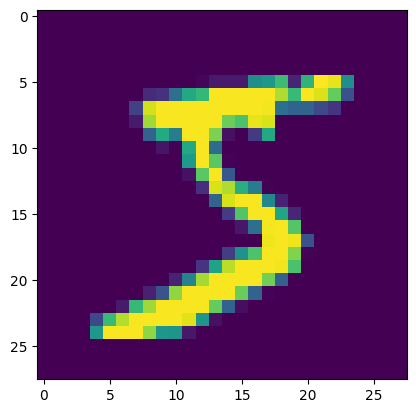

Label: 5


In [57]:
# Show the first element
import matplotlib.pyplot as plt
plt.imshow(x_train[0])
plt.show()
print(f"Label: {y_train[0]}")



In [58]:
# Scale images into the [0 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# Make images with size (28,28,1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# check shape
print(x_train.shape, x_test.shape)

(60000, 28, 28, 1) (10000, 28, 28, 1)


In [59]:
# convert class array into one-hot representation
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# we have seen this class is 5
print(y_train.shape)
print(y_train[0])

(60000, 10)
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [60]:
# Model/data parameters
num_classes = 10
input_shape = (28,28,1)

model = keras.Sequential(
    [
      keras.Input(shape=input_shape),
      layers.Conv2D(8, kernel_size=3, activation="relu"),
      layers.Conv2D(9, kernel_size=3, activation="relu"),
      layers.MaxPool2D(pool_size=2),
      layers.Conv2D(16, kernel_size=3, activation="relu"),
      layers.Conv2D(16, kernel_size=3, activation="relu"),
      layers.MaxPool2D(pool_size=2),
      layers.Flatten(),
      layers.Dropout(0.5),
      layers.Dense(num_classes, activation="softmax")
    ]
)
model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 24, 24, 9)      │           657 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 12, 12, 9)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 10, 10, 16)     │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 8, 8, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,939 (27.11 KB)

 Trainable params: 6,939 (27.11 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
from sklearn import metrics
batch_size = 128
epochs = 5

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.2)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5753 - loss: 1.2111 - val_accuracy: 0.9629 - val_loss: 0.1360
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9263 - loss: 0.2384 - val_accuracy: 0.9743 - val_loss: 0.0915
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9481 - loss: 0.1736 - val_accuracy: 0.9778 - val_loss: 0.0765
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9557 - loss: 0.1448 - val_accuracy: 0.9804 - val_loss: 0.0656
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9625 - loss: 0.1255 - val_accuracy: 0.9819 - val_loss: 0.0612


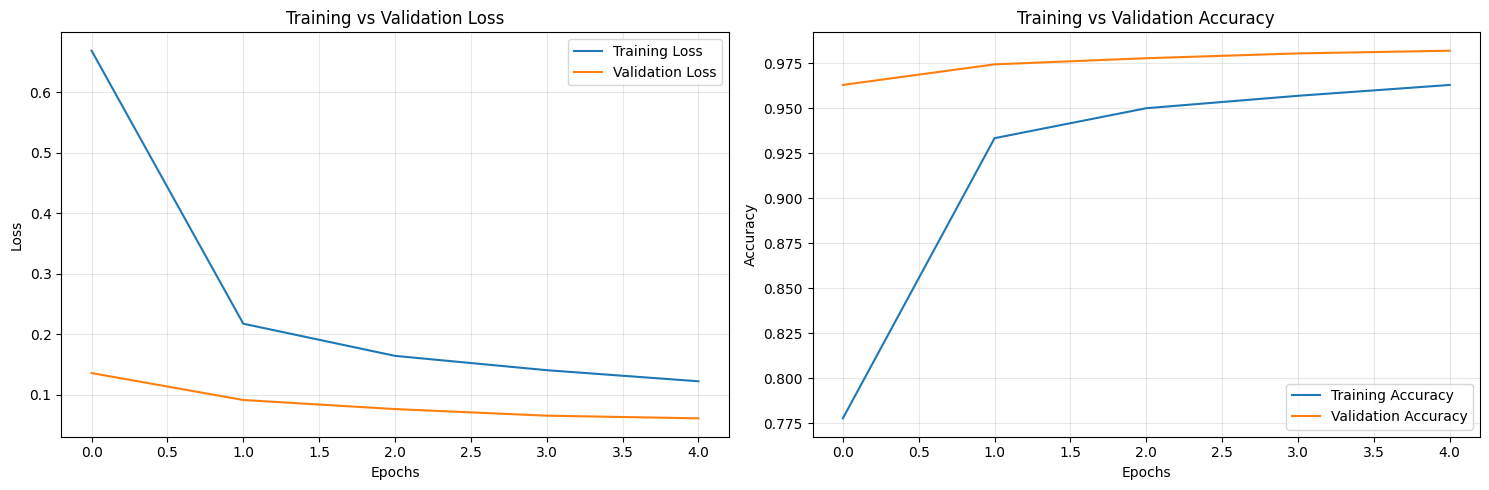

In [62]:
history_dict = history.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history_dict['loss'], label='Training Loss')
ax1.plot(history_dict['val_loss'], label='Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_dict['accuracy'], label='Training Accuracy')
ax2.plot(history_dict['val_accuracy'], label='Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [63]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss", score[0])
print("Test accuracy", score[1])

Test loss 0.054138075560331345
Test accuracy 0.982699990272522
